In [5]:
import pandas as pd
import numpy as np

# Link: https://www.kaggle.com/datasets/wasiqaliyasir/breast-cancer-dataset

df = pd.read_csv("Breast_cancer_dataset.csv")

print("\n5 Baris Pertama Data:")
print(df.head())

print("\n5 Baris Terakhir Data:")
print(df.tail())

print("\nDimensi Dataset:", df.shape, "(baris x kolom)")

print("\nNama Kolom:", list(df.columns))


5 Baris Pertama Data:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst 

In [8]:
print("         ANALISIS DATASET BREAST CANCER")

print("\n1. Informasi Umum Dataset:")
df.info()

print("\n2. Tipe Data Setiap Kolom:")
print(df.dtypes)

print("\n3. Jumlah Total Data (Baris) :", len(df))
print("   Jumlah Fitur Input (Kolom) :", len(df.columns) - 1, "fitur + 1 target")

print("\n4. Jumlah Label Kelas (Diagnosis):")
print(df['diagnosis'].value_counts())
print("   Total kelas :", df['diagnosis'].nunique())
print("   Nama kelas  :", list(df['diagnosis'].unique()))

print("\n5. Cek Missing Value (Nilai Kosong):")
missing = df.isnull().sum()
print(missing)
print("   Total missing value :", missing.sum())

print("\n6. Statistik Deskriptif Fitur Numerik:")
print(df.describe().round(2))

print("\n7. Informasi Tambahan:")

print("   Rata-rata Radius Mean      :",
      round(df['radius_mean'].mean(), 2))

print("   Radius Mean Minimum        :",
      round(df['radius_mean'].min(), 2))

print("   Radius Mean Maximum        :",
      round(df['radius_mean'].max(), 2))

print("   Rata-rata Texture Mean     :",
      round(df['texture_mean'].mean(), 2))

print("   Rata-rata Area Mean        :",
      round(df['area_mean'].mean(), 2))

print("   Rata-rata Smoothness Mean  :",
      round(df['smoothness_mean'].mean(), 4))

print("\n8. Distribusi Diagnosis Tumor:")

diagnosis_map = {
    'M': 'Malignant (Ganas)',
    'B': 'Benign (Jinak)'
}

print(df['diagnosis'].map(diagnosis_map).value_counts())

         ANALISIS DATASET BREAST CANCER

1. Informasi Umum Dataset:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se             

C:\Users\HP\AppData\Local\Temp\ipykernel_4356\18914296.py:43: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0, 1].boxplot(


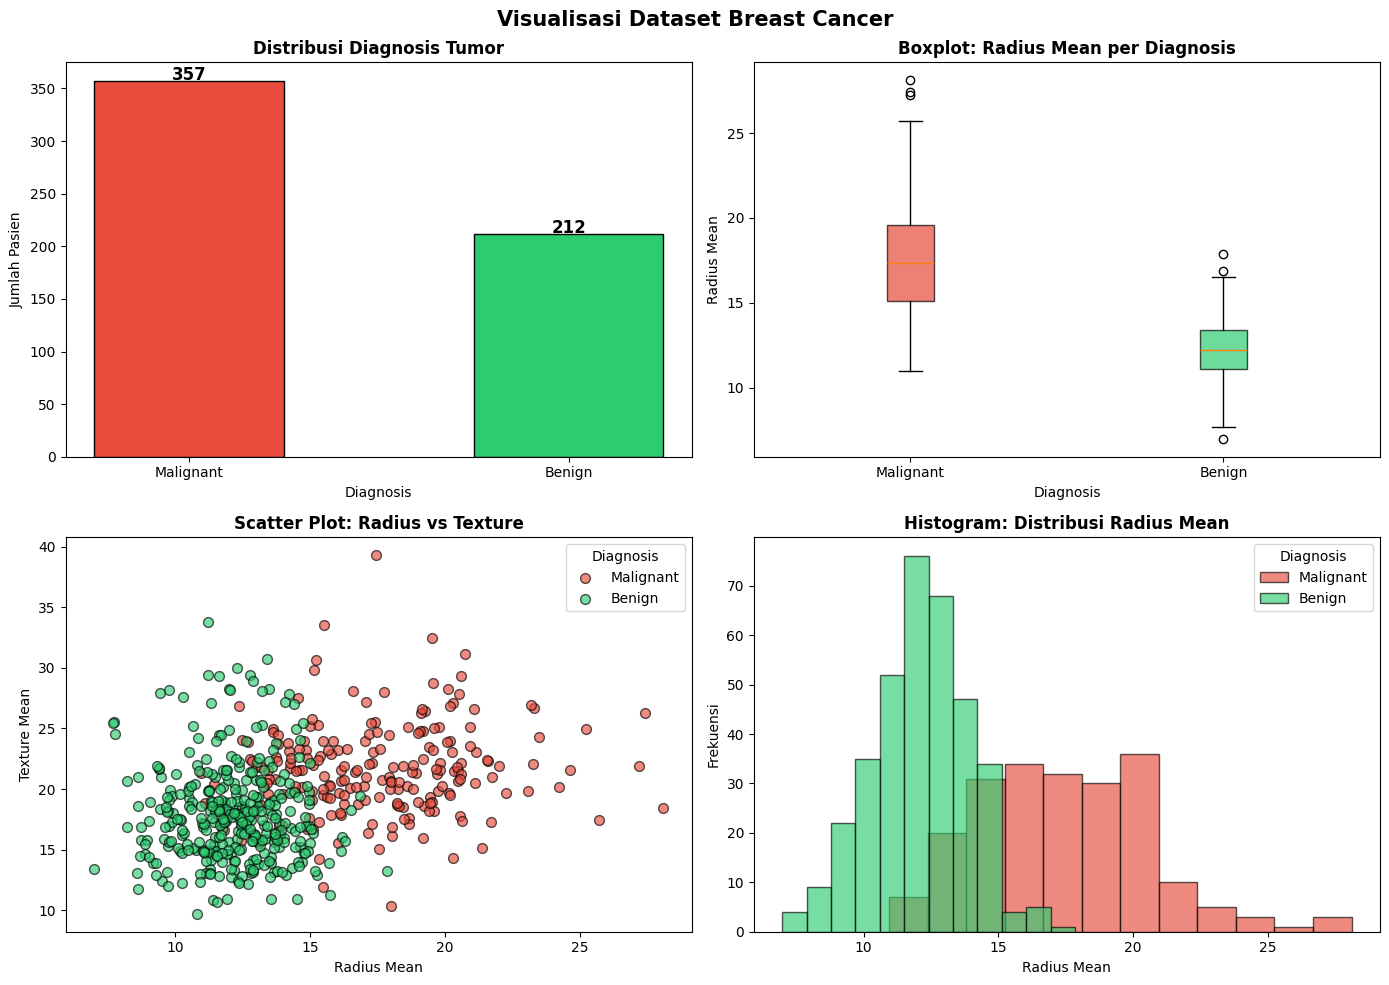

Grafik berhasil ditampilkan!


In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Visualisasi Dataset Breast Cancer', fontsize=15, fontweight='bold')

colors_label = {'M': '#e74c3c', 'B': '#2ecc71'}

# =====================================================
# Grafik 1: Distribusi Kelas Diagnosis
# =====================================================

counts = df['diagnosis'].value_counts()

bars = axes[0, 0].bar(
    ['Malignant', 'Benign'],
    counts.values,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    width=0.5
)

axes[0, 0].set_title('Distribusi Diagnosis Tumor', fontweight='bold')
axes[0, 0].set_xlabel('Diagnosis')
axes[0, 0].set_ylabel('Jumlah Pasien')

for bar, val in zip(bars, counts.values):
    axes[0, 0].text(
        bar.get_x() + bar.get_width()/2,
        val + 1,
        str(val),
        ha='center',
        fontweight='bold',
        fontsize=12
    )

# =====================================================
# Grafik 2: Boxplot Radius Mean per Diagnosis
# =====================================================

malignant_radius = df[df['diagnosis'] == 'M']['radius_mean']
benign_radius = df[df['diagnosis'] == 'B']['radius_mean']

bp = axes[0, 1].boxplot(
    [malignant_radius, benign_radius],
    labels=['Malignant', 'Benign'],
    patch_artist=True
)

for patch, color in zip(bp['boxes'], ['#e74c3c', '#2ecc71']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[0, 1].set_title('Boxplot: Radius Mean per Diagnosis', fontweight='bold')
axes[0, 1].set_xlabel('Diagnosis')
axes[0, 1].set_ylabel('Radius Mean')

# =====================================================
# Grafik 3: Scatter Plot Radius Mean vs Texture Mean
# =====================================================

for label, color in colors_label.items():

    subset = df[df['diagnosis'] == label]

    axes[1, 0].scatter(
        subset['radius_mean'],
        subset['texture_mean'],
        c=color,
        label='Malignant' if label == 'M' else 'Benign',
        alpha=0.65,
        edgecolors='black',
        s=50
    )

axes[1, 0].set_title('Scatter Plot: Radius vs Texture', fontweight='bold')
axes[1, 0].set_xlabel('Radius Mean')
axes[1, 0].set_ylabel('Texture Mean')
axes[1, 0].legend(title='Diagnosis')

# =====================================================
# Grafik 4: Histogram Radius Mean
# =====================================================

for label, color in colors_label.items():

    subset = df[df['diagnosis'] == label]

    axes[1, 1].hist(
        subset['radius_mean'],
        bins=12,
        alpha=0.65,
        label='Malignant' if label == 'M' else 'Benign',
        color=color,
        edgecolor='black'
    )

axes[1, 1].set_title('Histogram: Distribusi Radius Mean', fontweight='bold')
axes[1, 1].set_xlabel('Radius Mean')
axes[1, 1].set_ylabel('Frekuensi')
axes[1, 1].legend(title='Diagnosis')

plt.tight_layout()
plt.show()

print("Grafik berhasil ditampilkan!")

Penjelasan Visualisasi:

1. Distribusi Kelas (Bar Chart):
Dataset breast cancer memiliki distribusi kelas yang cukup baik, yaitu sekitar 357 data Benign (jinak) dan 212 data Malignant (ganas). Jumlah data jinak lebih banyak dibanding ganas, tetapi perbedaannya masih cukup wajar sehingga dataset tetap layak digunakan untuk klasifikasi menggunakan Decision Tree.

2. Boxplot Radius Mean:
Tumor dengan diagnosis Malignant (ganas) memiliki nilai radius_mean yang lebih tinggi dibanding tumor Benign (jinak). Median radius tumor ganas berada di kisaran 17–18, sedangkan tumor jinak berada di sekitar 12–13.
Terlihat juga beberapa outlier pada kelas Benign dengan ukuran radius cukup besar, namun secara umum tumor ganas memiliki ukuran yang lebih besar dan lebih menyebar.

3. Scatter Plot Radius Mean vs Texture Mean:
Visualisasi menunjukkan bahwa tumor ganas cenderung memiliki kombinasi:
-radius_mean tinggi
-texture_mean tinggi
Sebaliknya, tumor jinak lebih banyak terkonsentrasi pada area:
-radius lebih kecil
-texture lebih rendah
Terdapat beberapa titik yang saling berdekatan antar kelas, tetapi sebagian besar data masih dapat dipisahkan dengan cukup jelas oleh model klasifikasi.

4. Histogram Radius Mean:
Mayoritas tumor jinak memiliki nilai radius_mean pada rentang sekitar 10–15.
Sedangkan tumor ganas lebih banyak muncul pada rentang 15-25.

decision tree

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

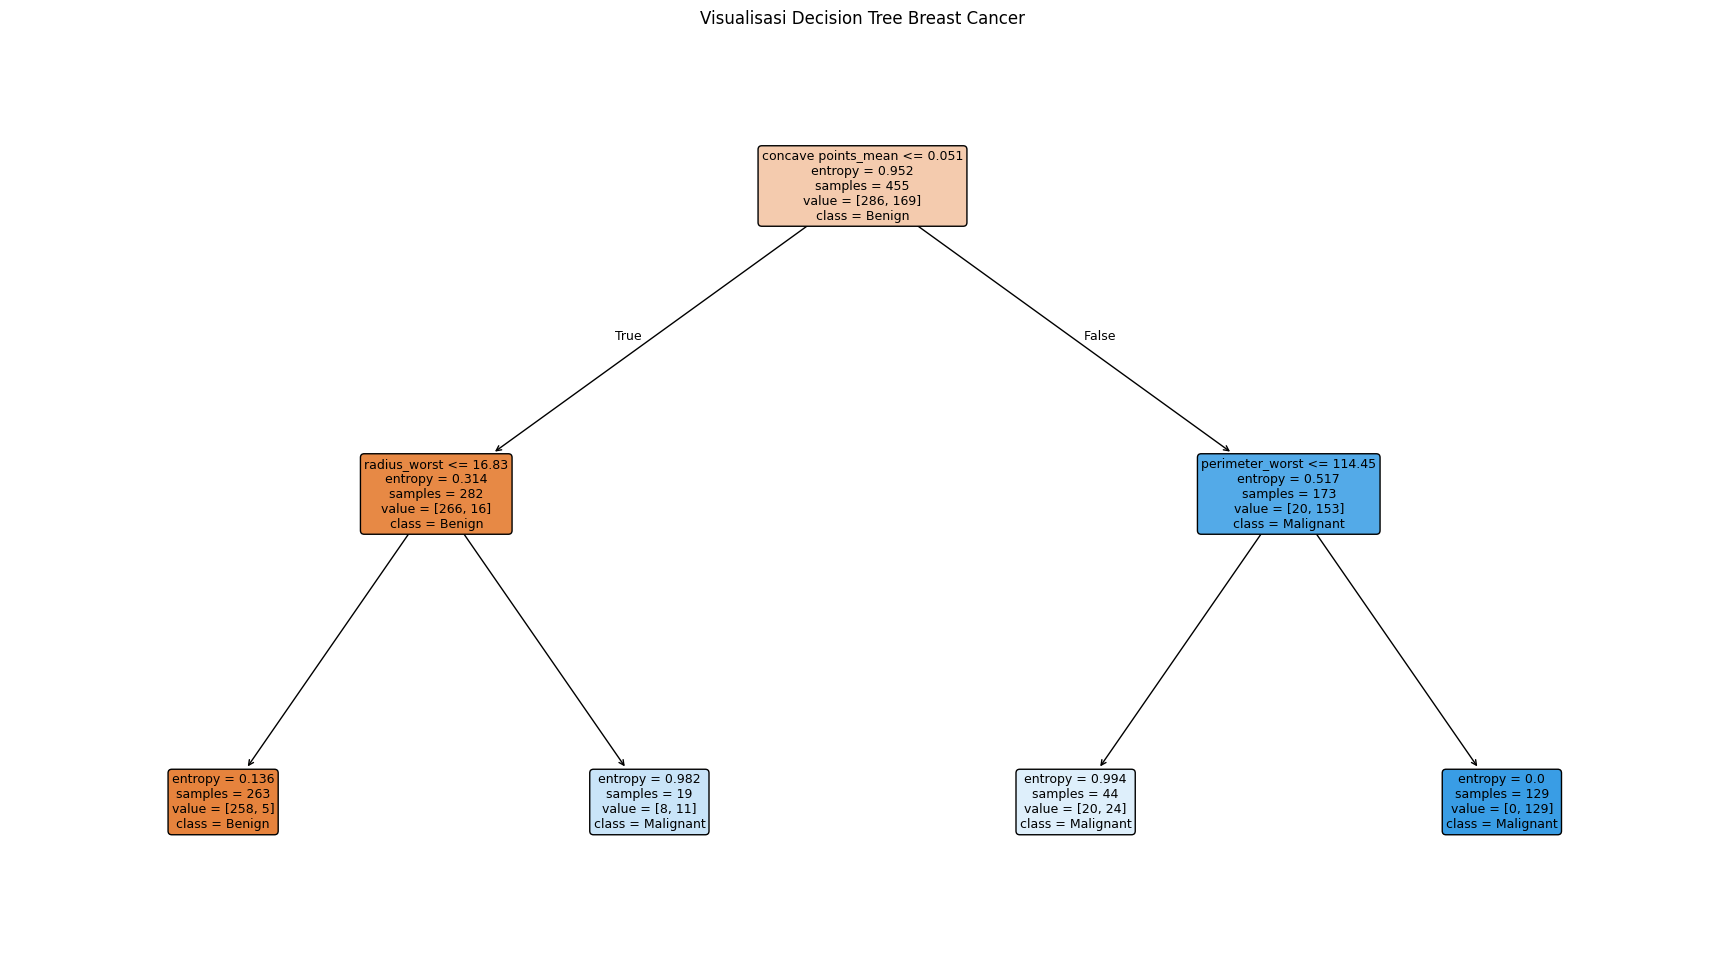

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_text
from sklearn.tree import plot_tree
from sklearn.metrics import accuracy_score

df = pd.read_csv("Breast_cancer_dataset.csv")

# Menampilkan 5 data pertama
print(df.head())

df['diagnosis'] = df['diagnosis'].map({
    'B': 0,   # Benign
    'M': 1    # Malignant
})

# Menghapus kolom id jika ada
if 'id' in df.columns:
    df = df.drop('id', axis=1)

# Menghapus kolom kosong jika ada
if 'Unnamed: 32' in df.columns:
    df = df.drop('Unnamed: 32', axis=1)

# Target
y = df['diagnosis']

# Fitur input
X = df.drop('diagnosis', axis=1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=2,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

akurasi = accuracy_score(y_test, y_pred)

print("\nAkurasi Model :", round(akurasi * 100, 2), "%")

rules = export_text(
    model,
    feature_names=list(X.columns)
)

print("\nRULE DECISION TREE:\n")
print(rules)

plt.figure(figsize=(22,12))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=['Benign', 'Malignant'],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Visualisasi Decision Tree Breast Cancer")
plt.show()